# **Surface codes**
In this notebook I show some memory experiments involving simulations of surface codes. Altough the content is of didactic purpose only, familiarity with the essential concepts of QEC are assumed. Furthermore if you want to run the code yourself you need a (free) account on the IBM quantum platform.



## 1.   **Simulation on a real quantum computer**
While the ideal hardware layout for surfaces code can be implemented, most computers need to swap qubits in oredr to implement a surface code. I will first explore some of the challenges posed by this fact.





In [46]:
#Hide output with capture magic command
%%capture
!pip install qiskit
!pip install pylatexenc
!pip install qiskit-aer
!pip install qiskit-ibm-runtime
!pip install pymatching
!pip install stim
!pip install sinter


In [47]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile, visualization
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer import AerSimulator
import stim
import pymatching
import sinter
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import SVG, display, HTML, Image



QiskitRuntimeService.save_account(
    token="your token", #Insert the token generated with your account here
    overwrite=True
)

In the figure below you can see on the left the usual representation of the $d=3$ surface code (black dots are data qubits, red ones ancillas for Z-stabilizers measurements, blue ones correspond to X-stabilizers), while on the right I highlighted connection between qubits. (The usual representation may be misleading because black lines actually don't correspond to connections).

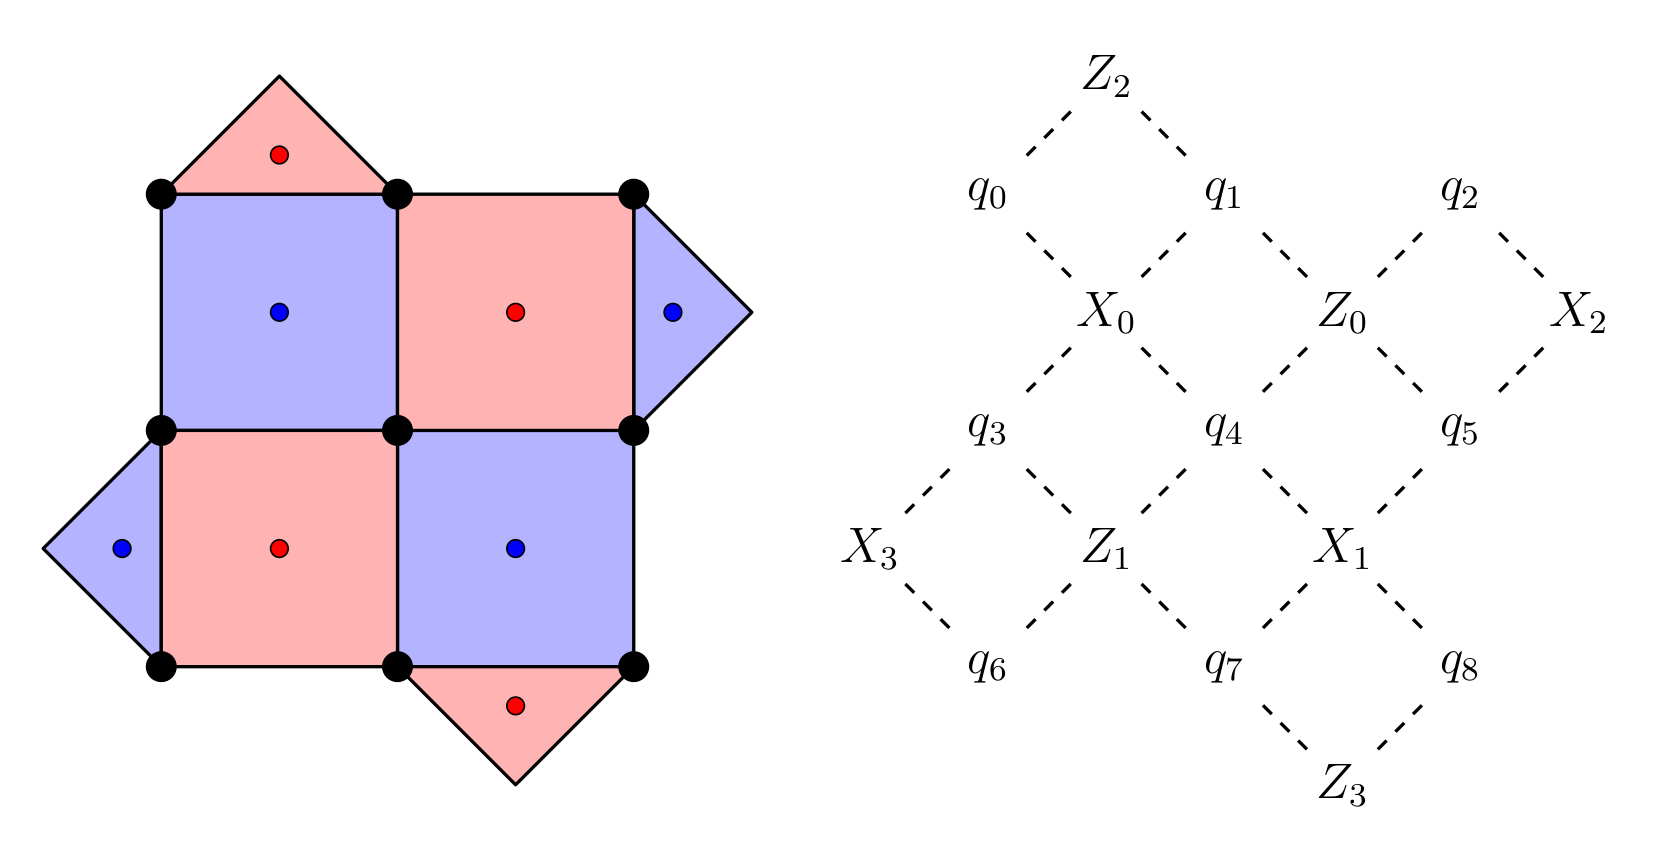

In [48]:
display(Image('surface code.png'))

Next I use qiskit to create the circuit corresponding to the above diagram.

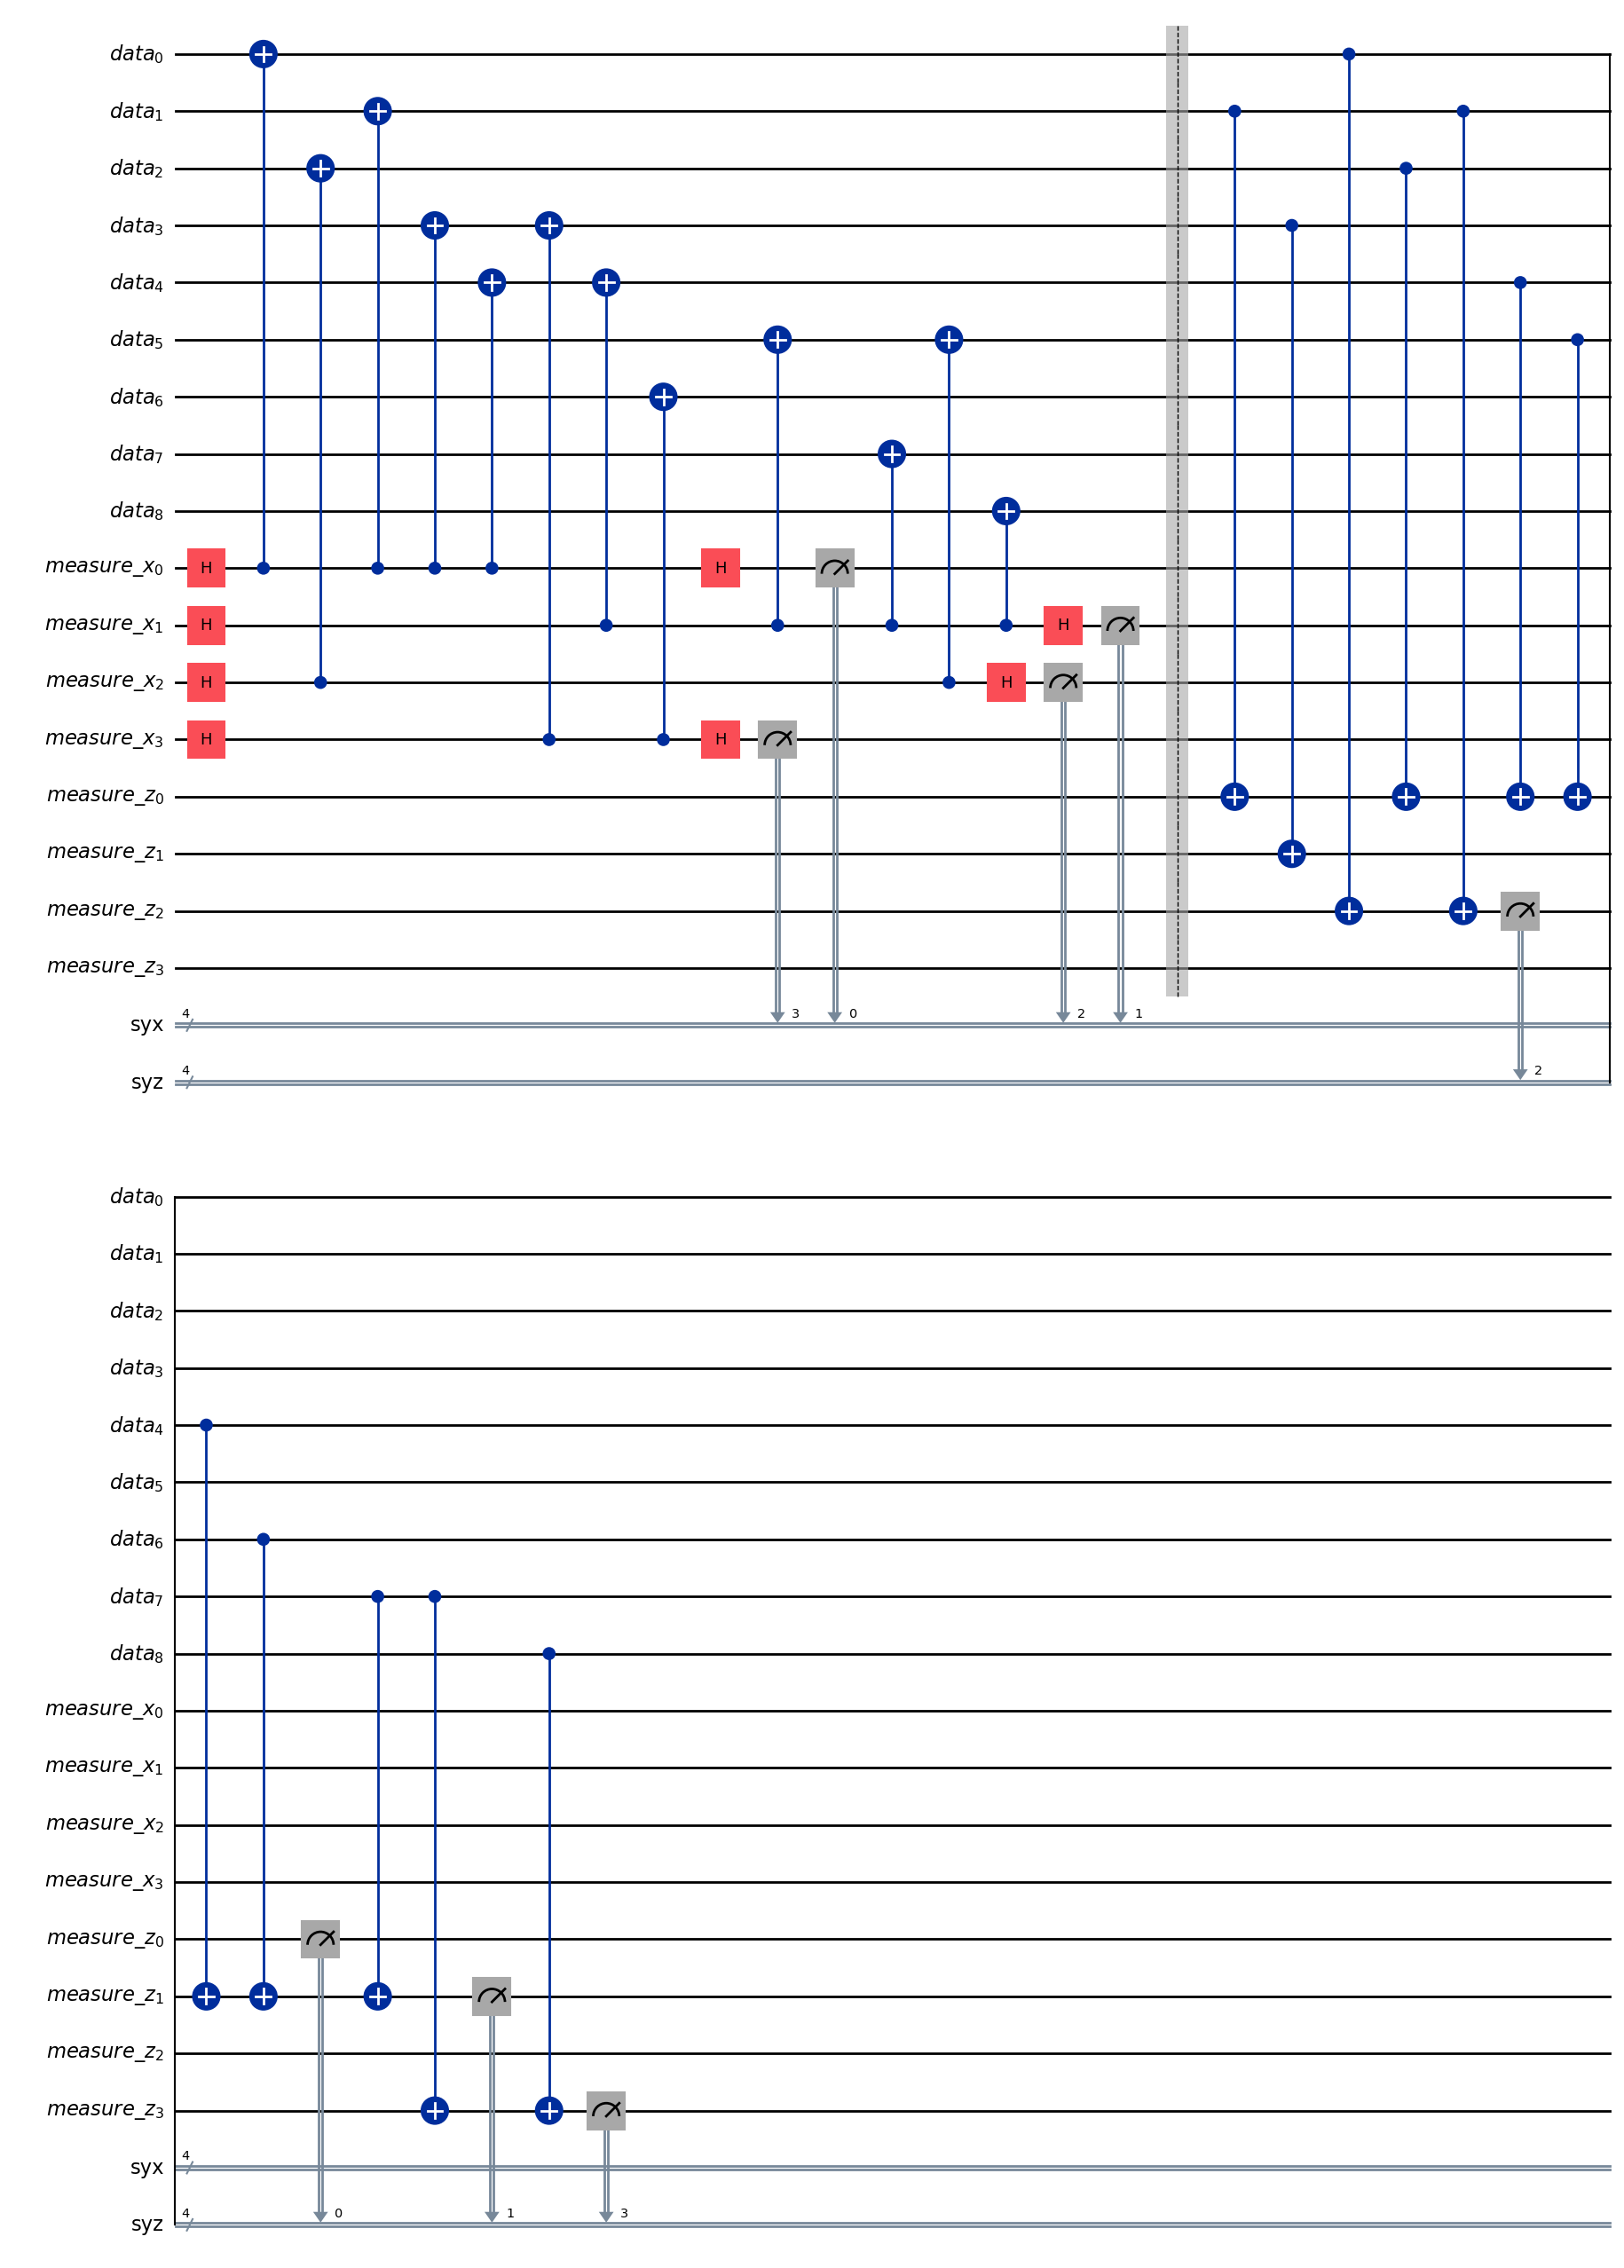

In [49]:
# ---------------------------------------------------------
# 1. DEFINE THE QUANTUM HARDWARE REGISTERS
# ---------------------------------------------------------
data = QuantumRegister(9, 'data')
mx = QuantumRegister(4, 'measure_x')
mz = QuantumRegister(4, 'measure_z')

# Classical registers to hold the syndromes
syndrome_x = ClassicalRegister(4, 'syx')
syndrome_z = ClassicalRegister(4, 'syz')

qc = QuantumCircuit(data, mx, mz, syndrome_x, syndrome_z)

# ---------------------------------------------------------
# 2. DEFINE THE LATTICE CONNECTIONS (PLAQUETTES)
# ---------------------------------------------------------
# These arrays map which data qubits each measure qubit interacts with,
# note that they correspond exactly to the above figure.
x_plaquettes = [[0, 1, 3, 4], [4, 5, 7, 8], [2, 5], [3, 6]]
z_plaquettes = [[1, 2, 4, 5], [3, 4, 6, 7], [0, 1], [7, 8]]

# ---------------------------------------------------------
# 3. SYNDROME EXTRACTION CYCLE
# ---------------------------------------------------------
# Measure X-Stabilizers
qc.h(mx)
for i, plaquette in enumerate(x_plaquettes):
    for q in plaquette:
        qc.cx(mx[i], data[q])
qc.h(mx)
qc.measure(mx, syndrome_x)

qc.barrier()

# Measure Z-Stabilizers
for i, plaquette in enumerate(z_plaquettes):
    for q in plaquette:
        qc.cx(data[q], mz[i])
qc.measure(mz, syndrome_z)

qc.draw('mpl')

This circuit is not yet ready to collect X syndromes, but before to clarify and fix this problem (and before our circuit grows too big) we can simulate it anyway and see what happens. First we choose the computer we want to use and transpile the circuit to adapt it to the hardware layout:

In [50]:
service = QiskitRuntimeService()

#Choose the real quantum computer you want to simulate
real_backend = service.backend("ibm_fez")

#Automatically build a simulator mirroring the real device
simulator = AerSimulator.from_backend(real_backend)

qiskit_runtime_service.__init__:WARNING:2026-08-02 21:27:54,979: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-08-02 21:27:54,986: Using instance: open-instance, plan: open


## 1.1 **Transpilation**
Before to transpile the circuit a few words are needed. Transpilation can't be done in optimal way in reasonable time, thus is done by a randomized heuristic algorithm which would map to different qubits via different circuits at each call. To always get the same result one has to specify the `seed_transpiler` when calling the method `transpile`. Here I do that because I want to briefly comment the output, but I think it is a good practice in general when testing error correcting codes because otherwise the result would depend on how "lucky" you are with the transpilation output.

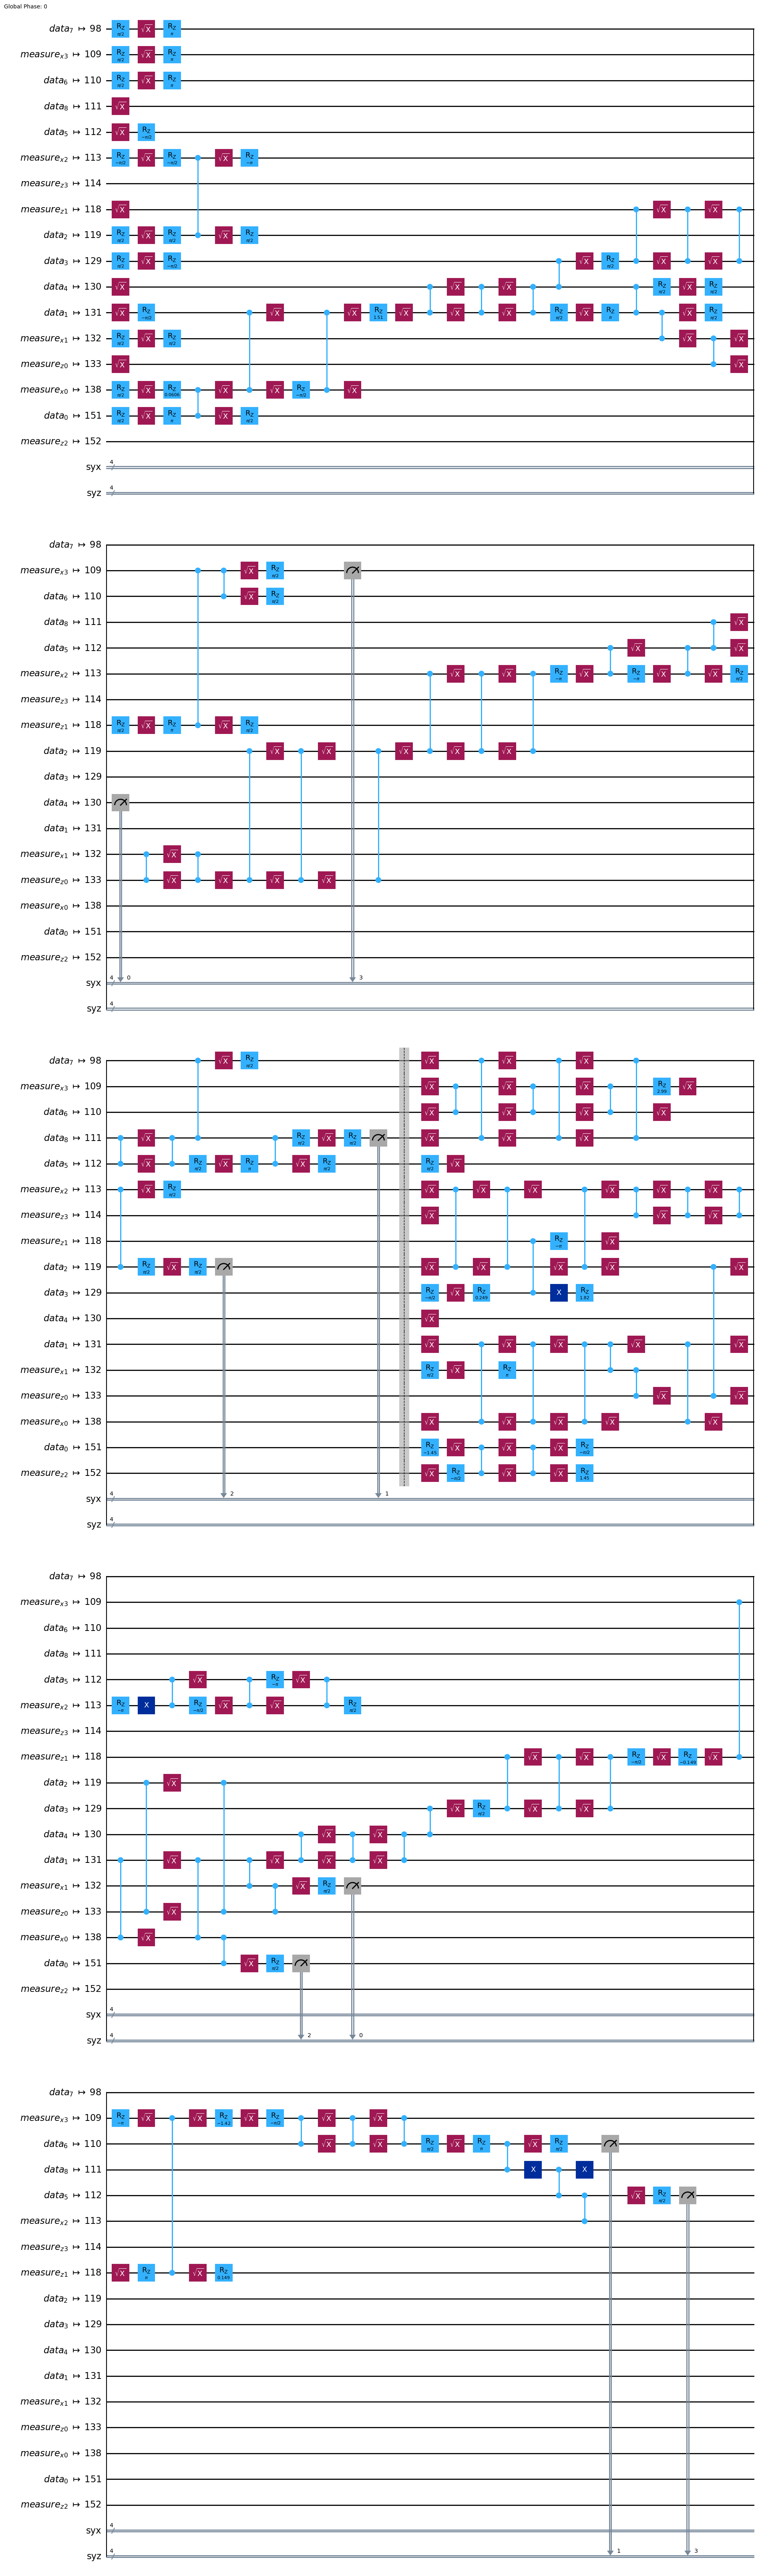

In [51]:
#stim_basis = ['h', 's', 'sdg', 'cx', 'cz', 'id', 'reset', 'measure']
transpiled_circuit = transpile(qc, backend=simulator, optimization_level=3, seed_transpiler=1)
transpiled_circuit.draw('mpl')

The transpiled circuit is big but still readable. First observe that the following sequence of gates is equivalent to a SWAP modulo Z rotations that usually can be moved at the beginning of the circuit. The symmetric blue 2-qubits gates are CZ gates (they are in fact independent from choice of control and target!).

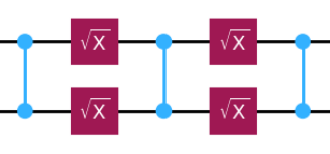

In [52]:
display(Image('SWAP gate.png'))

Next we need to look at the hardware layout to see  which qubits are connected, you can do this in the dashboard of your IBM account or simply look at the screenshot I took from there (the numbers correspond to qubits in the respective row, from left to right):

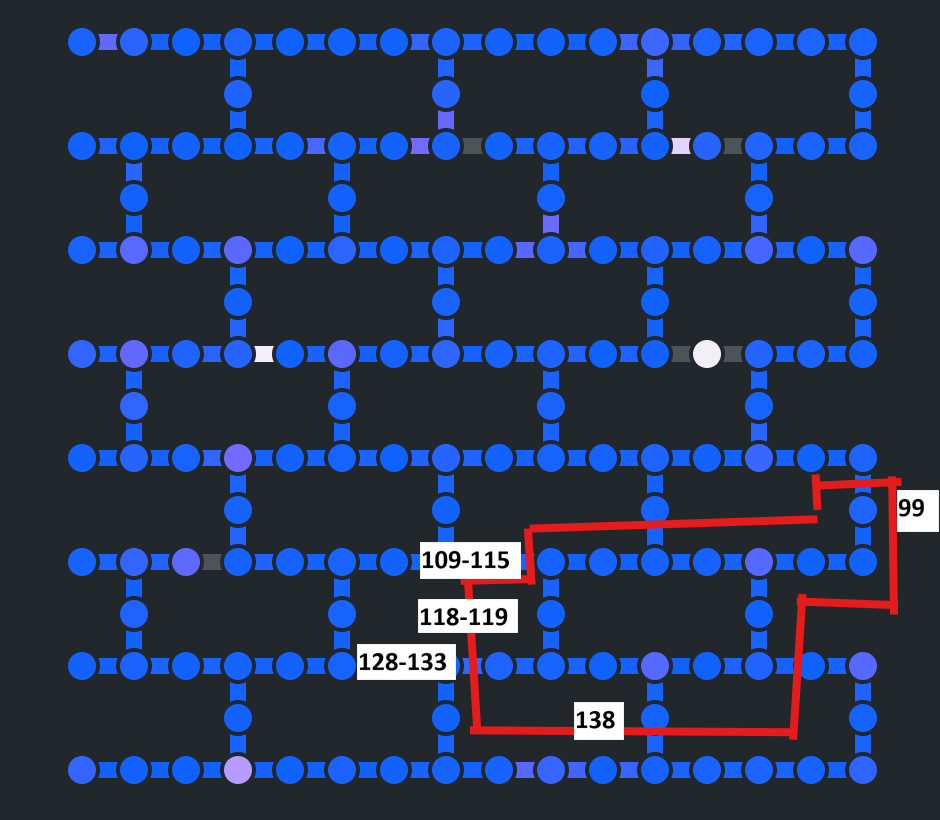

In [53]:
display(Image('IBM fez layout.png'))

Now you can check that the transpiled circuit drawn by Qiskit realizes the operations of the original one, involving only 2-qubits gates acting between qubits that are adjacent in the hardware layout. For example is very easy to check the behaviour of $Q_{109}$ (I use capital $q$ for qubits on the real computer), alias the ancillary qubit corresponding to the $X_3$ stabilizer: it correctly applies the CNOT to $Q_{110}$ (connected at his right) after that this one has been swapped with $Q_{111}$, and thus encode $q_3$, and to $Q_{118}$ (connected below it) encoding $q_6$.

## 1.2 **State initialization problem**
We now look ar the circuit's syndrome measurements.

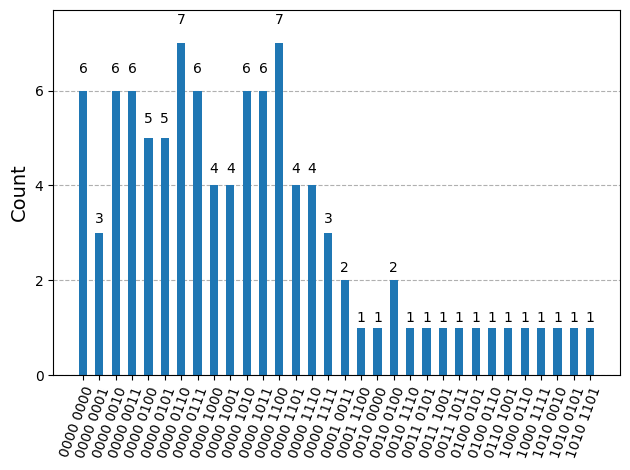

In [54]:
job = simulator.run(transpiled_circuit, shots=100)
result = job.result()

#---------------------------------------------
# Histogram visualization
#---------------------------------------------
visualization.plot_histogram(result.get_counts())

In [55]:
#-----------------------------------------
# Table visualization
#-----------------------------------------

counts = result.get_counts()
df_counts = pd.DataFrame(list(counts.items()), columns=['Syndrome_Raw', 'Count'])

# Split the syndrome string into two columns (Z and X)
df_counts[['Syndrome Z', 'Syndrome X']] = df_counts['Syndrome_Raw'].str.split(' ', expand=True)
df_counts = df_counts[['Syndrome Z', 'Syndrome X', 'Count']]
df_counts = df_counts.sort_values(by='Count', ascending=False).reset_index(drop=True)

pd.set_option('display.max_rows', None)
display(df_counts)

,Syndrome Z,Syndrome X,Count
0,0000,1100,7
1,0000,0110,7
2,0000,1011,6
3,0000,0000,6
4,0000,1010,6
5,0000,0010,6
6,0000,0111,6
7,0000,0011,6
8,0000,0100,5
9,0000,0101,5


From the data above we see that we get reasonable measurements for Z-syndromes of a logical state, while X-syndromes are equally distibuted. It is easy to see that this must be the case: while the circuit only involves GHZ states when measuring Z-stabilizers, thus parity check is correctly triggered by bit-flips, there are two problems with detecting Z-errors. A trivial fact is that Z-errors act as the identity on the initial state $\vert 0 \rangle^9$, the second is that the initial state is not a logical state.  
To understand a solution to this problem is useful to recall how stabilizers detect errors. Consider the circuit below (measurement is in X-basis), where you want to know if a logical state $\vert \psi \rangle$ (which may be built by an arbitrary number of qubits) has suffered or not an error represented by a gate $E$. In order to do so one can apply a controlled gate $g$, with $g$ a stabilizer, then:


1.   The error didn't happen, $g$ acts as the identity on logical states by definition, thus the final state is identical to the initial one $$\vert + \rangle \otimes \vert \psi \rangle $$
and $\vert + \rangle$ is measured, given syndrome 0.
2.   The error affected $\vert \psi \rangle$, by definition errors anticommute with stabilizers, thus the resulting state is
$$\vert 0 \rangle \otimes E\vert \psi \rangle + \vert 1 \rangle \otimes gE \vert \psi \rangle = \vert 0 \rangle \otimes E\vert \psi \rangle - \vert 1 \rangle \otimes Eg \vert \psi \rangle = \vert - \rangle \otimes E\vert \psi \rangle$$
and $\vert - \rangle$ is measured, giving syndrome 1.

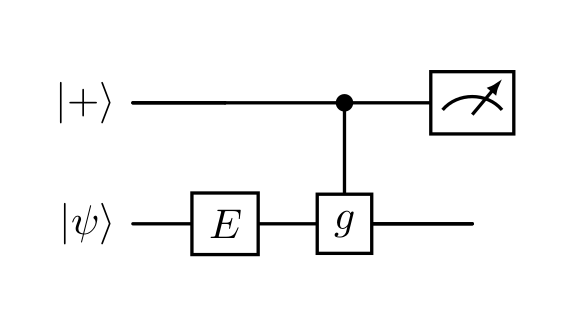

In [56]:
display(Image('Stabilizer meas circuit.png'))

When $\psi$ is not logical we need to find some other way to get rid of $g$, it is natural to make use of the property that stabilizers square to the identity operator. I will give two solutions, the second one, a bit more sophisticated, is what we will use in the simulation.  
Pheraps the simplest solution is to add a controlled stabilizer gate as in the circuit below, then in absence of the error $E$ the initial state isn't modified and we will measure $\vert + \rangle$, while in the other case the final state is (I won't write explicitely tensor products from now on)
$$\vert 0 \rangle E\vert \psi \rangle + \vert 1 \rangle gEg\vert \psi \rangle = \vert 0 \rangle E\vert \psi \rangle - \vert 1 \rangle E\vert \psi \rangle = \vert - \rangle E\vert \psi \rangle$$
and we measure $\vert - \rangle$, thus we recover the same syndrome measurements that we would get in the logical state case.

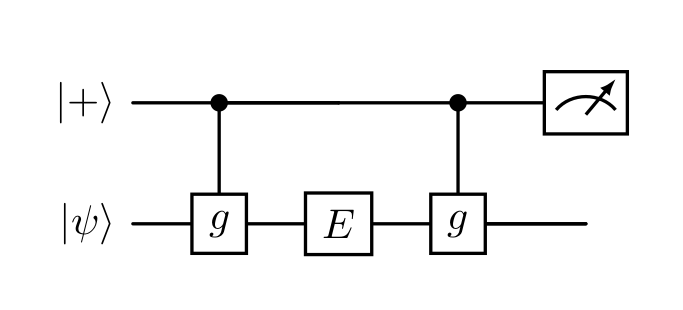

In [57]:
display(Image('Stabilizer non logical state.png'))

A second, more powerful, solution comes from the fact that errors conjugate the projector in the eigenspace of eigenvalue $+1$ of $g$ to the projector into the space of states with eigenvalue $-1$ wrt $g$, i.e.:
$$E(1+g) = (1-g)E$$
In particular you can work out the details of the circuit below to see that the first mesurement project $\vert \psi \rangle$ to $(1+g)\vert \psi \rangle$ if $\vert 0 \rangle$ is measured, to $(1-g)\vert \psi \rangle$ if $\vert 1 \rangle$ is measured; the successive measurements give the same syndrome value of the previous one if no error occurs, or the different value if the state is affected. It follows that one can construct an "effective" syndrome by XORs of consecutive measurements. Also note that ancillas are used only once, so one can use a single qubit for them, resetting its value after the measurements.  
It is important to perform many cycles of syndrome measurement because the readout process can be faulty itself, thus for example if you get two consecutive syndromes of value 1 it is highly probable that a measurement error happened, instead that two consecutive errors on the data.  
Of course you can iterate also the previous method, but that require almost the double of two qubit gates than this one.

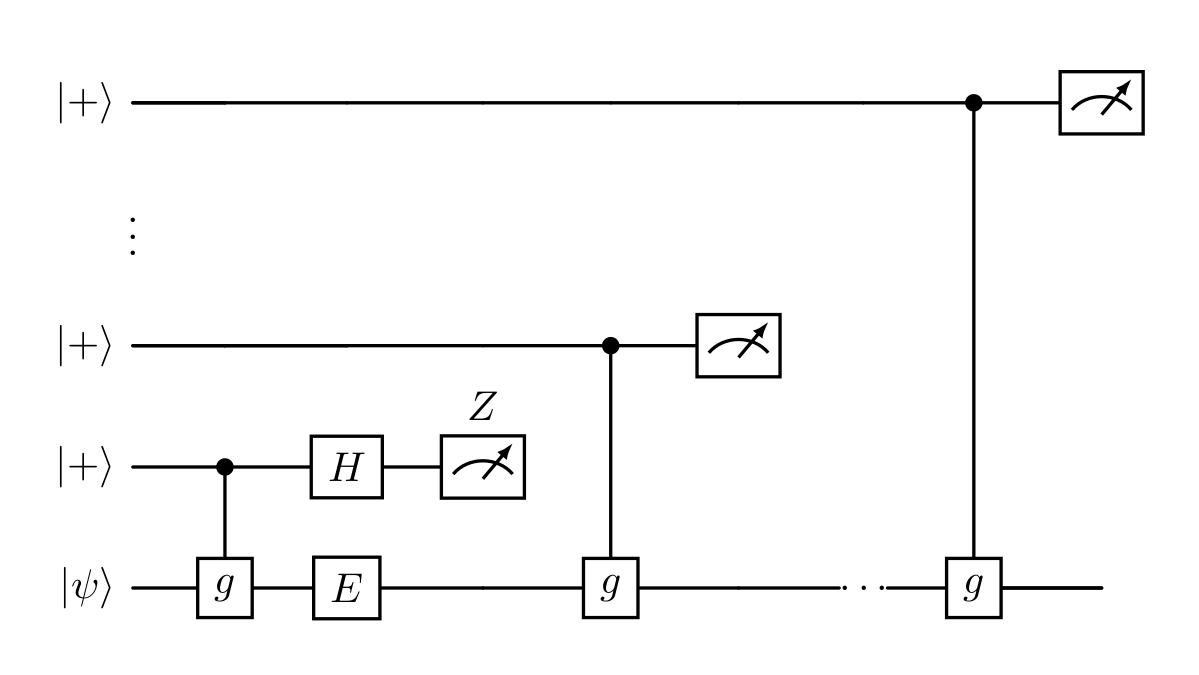

In [58]:
display(Image('Cycle meas.png'))

## 1.3 **Simulation**
I'll show how this construction can be easily implemented with `stim`. I will use the ideal (non-transpiled) circuit because it is already built in Stim library. Of course you could also build the transpiled one once, and iterarate using `stim.CircuitRepeatBlock`, and it would be interesting to compare that outcome with the idealized version. However inserting by hand all the errors declared by IBM would be pretty hard.  
Below you can see the $d=3$ rotated surface circuit automatically created by `stim`. Note  that the first iteration is always shown, the following ones are compactly represented inside big brakets with the number of repetitions at the bottom left. Also note that in the first round there is no detector for X-syndrome, consistenlty with the discussion above.  
Choosing all errors to have the same value seems reasonable given the experimental data available, and is necessary to draw the nice plots one uses to estimate the threshold of a code, which I will do next.

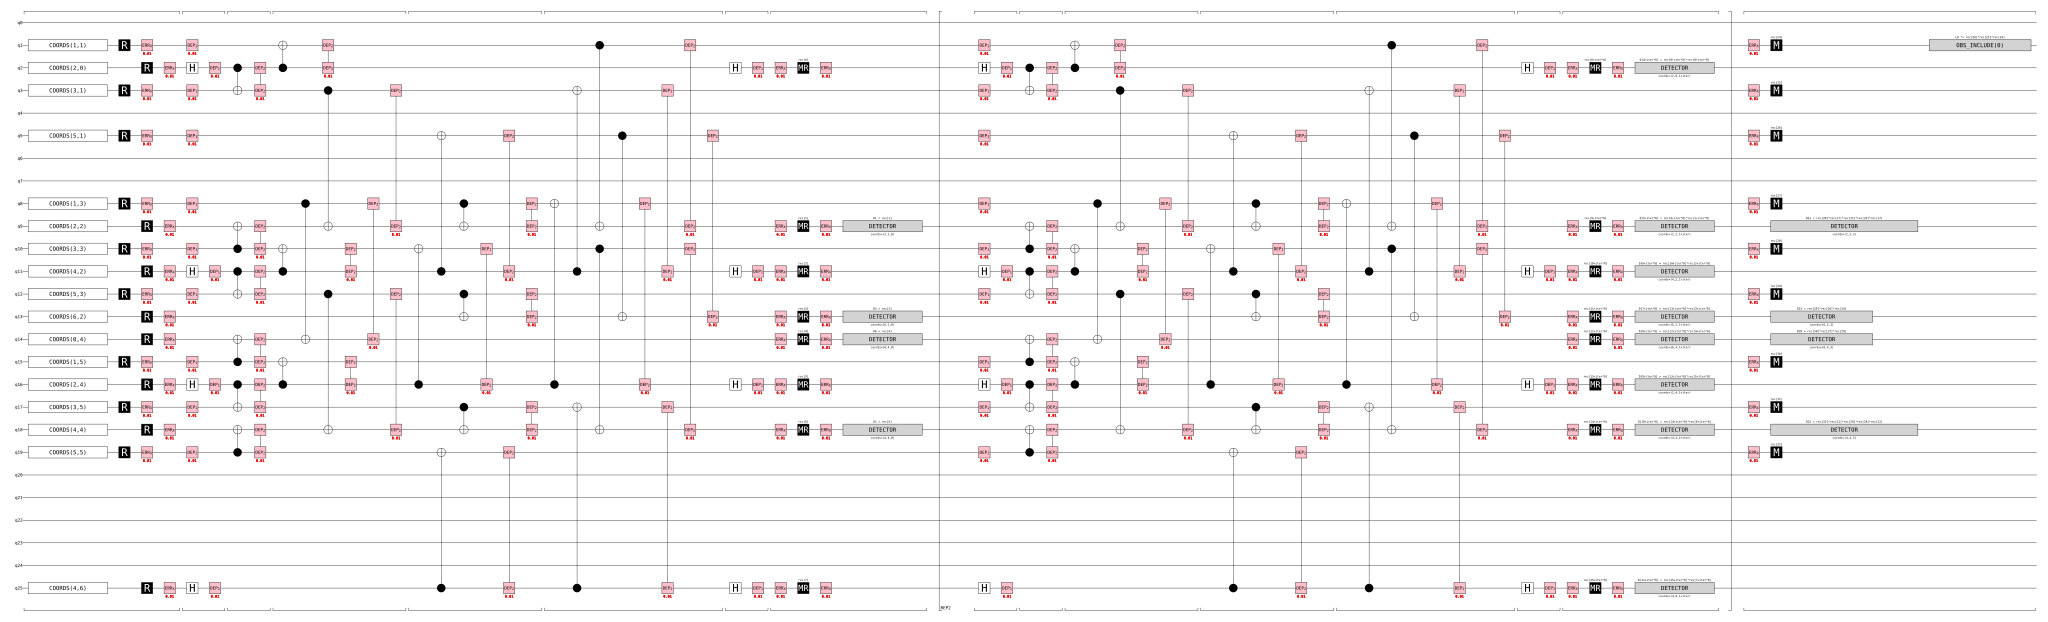

In [59]:
p = 0.01
repetition_circuit_example = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    distance=3,
    rounds=3,
    before_round_data_depolarization = p,
    before_measure_flip_probability = p,
    after_reset_flip_probability = p,
    after_clifford_depolarization=p,
)

repetition_circuit_example.diagram(type="timeline-svg")

Next I use `sinter` to easily compare physical error rates of surface code of different distances.

In [60]:
from typing import List

tasks = [
    sinter.Task(
        circuit=stim.Circuit.generated(
            "surface_code:rotated_memory_z",
            rounds=d,
            distance=d,
            before_round_data_depolarization = p,
            before_measure_flip_probability = p,
            after_reset_flip_probability = p,
            after_clifford_depolarization=p,
        ),
        json_metadata={'d': d, 'p': p},
    )
    for d in [3, 5, 7, 9]
    for p in [0.001, 0.002, 0.005, 0.008, 0.01, 0.02]
]

collected_stats: List[sinter.TaskStats] = sinter.collect(
    num_workers=4,
    tasks=tasks,
    decoders=['pymatching'],
    max_shots=100_000,
    max_errors=500,
)

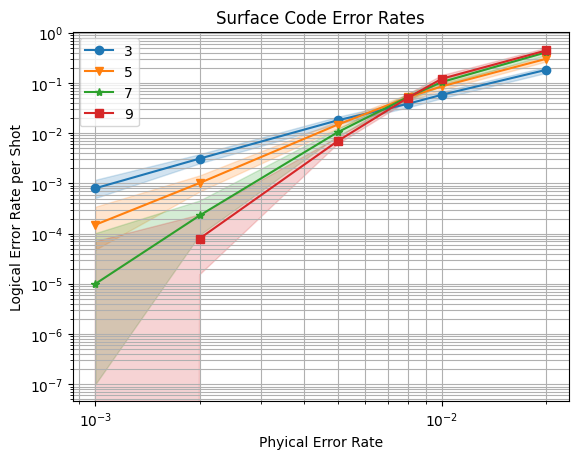

In [61]:
fig, ax = plt.subplots(1, 1)
sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    x_func=lambda stats: stats.json_metadata['p'],
    group_func=lambda stats: stats.json_metadata['d'],
)
ax.loglog()
ax.set_title("Surface Code Error Rates")
ax.set_xlabel("Phyical Error Rate")
ax.set_ylabel("Logical Error Rate per Shot")
ax.grid(which='major')
ax.grid(which='minor')
ax.legend()
fig.show()

In the plot above the lines intersect at a point whose x-coordinate is the threshold for the family of rotated surface codes, that means that oprating with a better error than that one can achieve a more reliable quantum computer increasing the distance of the code (that is, using more qubits).  
Note that the last red point is missing because no logical error was found and `sinter` deals with that situation (it can't estimate a probability) giving a `NaN` which is ignored in the plotting. This doesn't come as a surprise because the expected probability is of the order of the inverse of `max_num_shots`.